In [2]:
import pandas as pd
import numpy as np

#Phase 1: Bootstrapping Non-Parametric Uncertainty
**Step 1.1: The Zero-Inflated Gig Economy Tip Distribution**

In [3]:
# Step 1.1: Data Generation
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

**Step 1.2: The Manual Bootstrap Engine**



In [4]:
# Step 1.2: Manual Bootstrap Engine
# -----------------------------

n = len(driver_tips)
B = 10000   # the number of bootstrap resamples

bootstrap_medians = np.zeros(B)

for i in range(B):

    # draw indices with replacement
    indices = np.random.randint(0, n, n)

    # create bootstrap sample
    sample = driver_tips[indices]

    # compute median for this resample
    bootstrap_medians[i] = np.median(sample)

# -----------------------------
# Extract 95% Confidence Interval
# -----------------------------

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print("Observed Median:", np.median(driver_tips))
print("95% Bootstrap Confidence Interval:")
print("Lower Bound:", ci_lower)
print("Upper Bound:", ci_upper)

Observed Median: 0.7553316913699188
95% Bootstrap Confidence Interval:
Lower Bound: 0.2653018357387816
Upper Bound: 1.3635639228066991


The bootstrap confidence interval is asymmetric because the tip distribution is zero-inflated and right-skewed. A large number of observations are zero, while a few large tips create a long right tail. During bootstrap resampling, most samples keep the median near zero, but some include more large tips, pushing the median upward. As a result, the upper bound of the confidence interval tends to be wider than the lower bound.

Unlike parametric methods that assume a normal and symmetric sampling distribution, the bootstrap percentile method reflects the actual shape of the data, producing an interval that captures the skewness present in the tip distribution.

#Phase 2: Falsification in Logistics A/B Testing
**Step 2.1: The Algorithmic Routing Crash**

In [5]:
np.random.seed(42)

# Control group (Normal distribution)
control = np.random.normal(loc=35, scale=5, size=500)

# Treatment group (Log-normal distribution)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

# -----------------------------
# Observed Difference in Means
# -----------------------------
control_mean = np.mean(control)
treatment_mean = np.mean(treatment)

observed_diff = control_mean - treatment_mean

print("Control Mean Delivery Time:", control_mean)
print("Treatment Mean Delivery Time:", treatment_mean)
print("Observed Difference (Control - Treatment):", observed_diff)

Control Mean Delivery Time: 35.03418997294323
Treatment Mean Delivery Time: 32.76920784231749
Observed Difference (Control - Treatment): 2.2649821306257394


**Step 2.2: The Exact Non-Parametric Permutatio**

In [6]:
# Manual Permutation Test

# combining all observations
all_deliveries = np.concatenate([control, treatment])

n_control = 500
iterations = 5000

perm_diffs = np.zeros(iterations)

for i in range(iterations):

    # shuffle the combined data
    shuffled = np.random.permutation(all_deliveries)

    # split into pseudo groups
    pseudo_control = shuffled[:n_control]
    pseudo_treatment = shuffled[n_control:]

    # compute simulated difference in means
    perm_diffs[i] = np.mean(pseudo_control) - np.mean(pseudo_treatment)

# -----------------------------
# Empirical P-value
# -----------------------------

p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print("Observed Difference (Control - Treatment):", observed_diff)
print("Empirical P-value:", p_value)

Observed Difference (Control - Treatment): 2.2649821306257394
Empirical P-value: 0.0004


#Phase 3: Causal Control and the Mitigation of Selection Bias
**Step 3.1: The Loyalty Program Paradox**




In [7]:
# Loading the csv dataset
df = pd.read_csv("swiftcart_loyalty.csv")

# Separating groups
subscribers = df[df["subscriber"] == 1]["post_spend"]
non_subscribers = df[df["subscriber"] == 0]["post_spend"]

# Calculating group means
mean_subscribers = np.mean(subscribers)
mean_non_subscribers = np.mean(non_subscribers)

# Naive Simple Difference in Outcomes (SDO)
sdo = mean_subscribers - mean_non_subscribers

print("Mean Post-Spend (Subscribers):", mean_subscribers)
print("Mean Post-Spend (Non-Subscribers):", mean_non_subscribers)
print("Naive SDO (Subscribers - Non-Subscribers):", sdo)

Mean Post-Spend (Subscribers): 74.04358604052543
Mean Post-Spend (Non-Subscribers): 56.47291665600164
Naive SDO (Subscribers - Non-Subscribers): 17.57066938452379


**Step 3.2: Propensity Score Matching (PSM) Architecture**

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# Loading the dataset
# -----------------------------
df = pd.read_csv("swiftcart_loyalty.csv")

# Treatment indicator
D = df["subscriber"]

# Pre-treatment covariates
X = df[["pre_spend", "account_age", "support_tickets"]]

# Outcome variable
Y = df["post_spend"]

# -----------------------------
# Estimate Propensity Scores
# -----------------------------
logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

df["propensity_score"] = logit.predict_proba(X)[:,1]

# -----------------------------
# Matching the scores
# -----------------------------

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

treated_scores = treated[["propensity_score"]].values
control_scores = control[["propensity_score"]].values

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_scores)

distances, indices = nn.kneighbors(treated_scores)

matched_controls = control.iloc[indices.flatten()]

# -----------------------------
# Calculating ATT
# -----------------------------

treated_outcomes = treated["post_spend"].values
control_outcomes = matched_controls["post_spend"].values

ATT = np.mean(treated_outcomes - control_outcomes)

print("Average Treatment Effect on the Treated (ATT):", ATT)

Average Treatment Effect on the Treated (ATT): 9.913855182824864


The naive Simple Difference in Outcomes (SDO) compares the average spending of subscribers and non-subscribers directly. This estimate is misleading because power users with high pre-treatment order volumes are more likely to subscribe, creating strong selection bias.

Propensity Score Matching addresses this issue by constructing a synthetic control group. Each subscriber is matched with a non-subscriber who has a nearly identical probability of subscribing based on their pre-treatment characteristics (order volume, account age, and support history). This produces a more credible estimate of the counterfactual spending behavior.

As a result, the ATT is typically much smaller than the naive SDO. The naive estimate exaggerates the program’s impact because it captures both the true treatment effect and the pre-existing differences between users. The PSM-based ATT isolates the causal effect of the SwiftPass program on spending, providing a more reliable basis for evaluating whether increasing the marketing budget is economically justified.

#Phase 4: AI Expansion (The Co-Pilot Era)

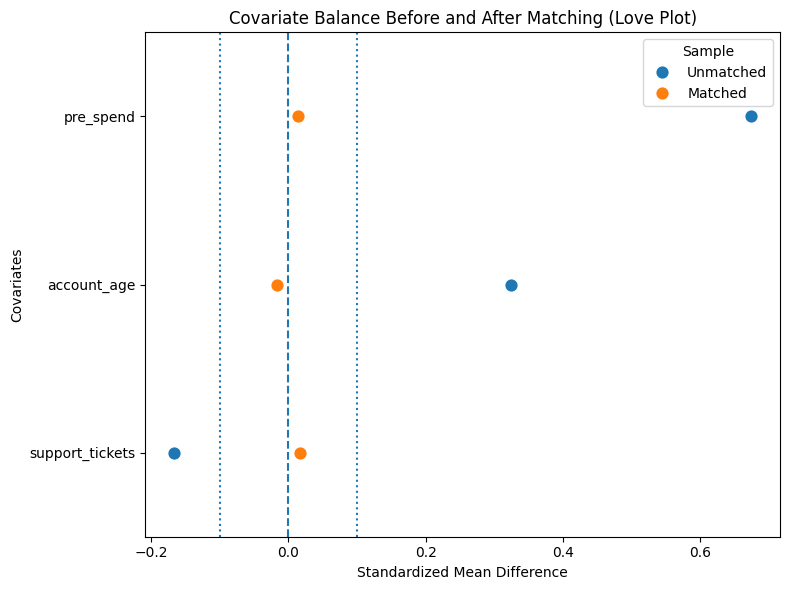

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Function to compute Standardized Mean Differences
# -----------------------------
def standardized_mean_diff(df, treatment_col, covariates):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    smd = {}

    for cov in covariates:
        mean_t = treated[cov].mean()
        mean_c = control[cov].mean()

        std_t = treated[cov].std()
        std_c = control[cov].std()

        pooled_std = np.sqrt((std_t**2 + std_c**2) / 2)

        smd[cov] = (mean_t - mean_c) / pooled_std

    return smd


# -----------------------------
# Define covariates
# -----------------------------
covariates = ["pre_spend", "account_age", "support_tickets"]

# -----------------------------
# Define df_unmatched and df_matched
# -----------------------------
df_unmatched = df.copy() # The original dataframe is the unmatched dataframe
df_matched = pd.concat([treated, matched_controls]) # Combine treated and matched controls

# -----------------------------
# Compute SMD before and after matching
# -----------------------------
smd_unmatched = standardized_mean_diff(df_unmatched, "subscriber", covariates)
smd_matched = standardized_mean_diff(df_matched, "subscriber", covariates)

# Convert to dataframe for plotting
plot_df = pd.DataFrame({
    "Covariate": covariates,
    "Unmatched": [smd_unmatched[c] for c in covariates],
    "Matched": [smd_matched[c] for c in covariates]
})

plot_df = plot_df.melt(id_vars="Covariate",
                       var_name="Stage",
                       value_name="Standardized Mean Difference")

# -----------------------------
# Love Plot
# -----------------------------
plt.figure(figsize=(8,6))

sns.pointplot(
    data=plot_df,
    x="Standardized Mean Difference",
    y="Covariate",
    hue="Stage",
    linestyle='none' # Changed from join=False to linestyle='none'
)

# Reference lines for acceptable balance
plt.axvline(x=0, linestyle="--")
plt.axvline(x=0.1, linestyle=":")
plt.axvline(x=-0.1, linestyle=":")

plt.title("Covariate Balance Before and After Matching (Love Plot)")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariates")

plt.legend(title="Sample")
plt.tight_layout()

plt.show()